In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)   # dataset has 107 columns - show all
DATA_DIR = "../data/"                        # notebook is in notebooks/, data is one level up

In [30]:
train_tte  = pd.read_csv(DATA_DIR + "train_tte.csv")
train_spec = pd.read_csv(DATA_DIR + "train_specifications.csv")

print("TTE shape:", train_tte.shape)
print("Spec shape:", train_spec.shape)
train_tte.head()

TTE shape: (23550, 3)
Spec shape: (23550, 9)


,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


In [31]:
train_spec.head()

,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1


In [32]:
counts = train_tte["in_study_repair"].value_counts()
print(counts)
print(f"\nFailure rate: {counts[1] / counts.sum() * 100:.1f}%")

in_study_repair
0    21278
1     2272
Name: count, dtype: int64

Failure rate: 9.6%


In [33]:
train_ops = pd.read_csv(DATA_DIR + "train_operational_readouts.csv")

print("Shape:", train_ops.shape)
print("Memory: {:.1f} MB".format(train_ops.memory_usage(deep=True).sum() / 1e6))
train_ops.head(3)

Shape: (1122452, 107)
Memory: 960.8 MB


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,1269525.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70.0,1435083.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8036751.0,0.0,1227.0,555.0,463.0,925.0,468.0,225.0,535.0,516.0,492.0,729.0,66.0,97056.0,2690052.0,2945268.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,858410.0,203.676778,111.91150,147.265389,200.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,744.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446956.0,411420.0,203024.0,26636.0,29156.0,7616.0,449537.0,233352.0,139920.0,12648.0,2813.0,224.0,53161.0,178881.0,138250.0,13328.0,3581.0,88.0,16361.0,131601.0,116541.0,13506.0,2856.0,48.0,6337.0,105412.0,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70.0,1440661.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8040811.0,0.0,1230.0,558.0,463.0,925.0,469.0,226.0,535.0,516.0,493.0,729.0,66.0,97056.0,2693100.0,2947368.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,860571.0,204.256750,112.92425,147.265389,201.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,745.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446964.0,411420.0,203027.0,26638.0,29157.0,7616.0,451193.0,233354.0,139920.0,12649.0,2813.0,224.0,53210.0,178883.0,138252.0,13328.0,3582.0,88.0,16368.0,131601.0,116542.0,13507.0,2856.0,48.0,6339.0,105413.0,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,1787736.0,1133132.0,598351.0,1167062.0,12314224.0,460240.0,3887.0,0.0,0.0,0.0,12777022.0,0.0,2136.0,954.0,850.0,1420.0,722.0,412.0,880.0,666.0,586.0,1143.0,162.0,181632.0,4249020.0,4630440.0,1539133.0,1421172.0,1039764.0,749472.0,740724.0,995796.0,574045.0,1379191.0,321.671972,157.31250,193.792833,263.577611,310.711861,366.149250,415.642472,484.391167,1146.111611,1286.536333,900.062917,1123.232556,1449.545611,2140.037472,5046.748278,1151.010139,3.320194,0.218806,0.056778,0.058444,756665.0,647348.0,286811.0,30967.0,31213.0,7745.0,633790.0,423395.0,271940.0,16190.0,3573.0,232.0,75038.0,352791.0,327992.0,17325.0,4451.0,92.0,24028.0,234737.0,216619.0,17000.0,3476.0,48.0,12055.0,167693.0,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0


In [34]:
counter_cols = ["171_0", "666_0", "427_0", "837_0", "309_0", "835_0", "370_0", "100_0"]

hist_groups = {}
for col in train_ops.columns:
    if col in ("vehicle_id", "time_step") or col in counter_cols:
        continue
    var_id = col.split("_")[0]
    hist_groups.setdefault(var_id, []).append(col)

for var, cols in hist_groups.items():
    print(f"Histogram {var}: {len(cols)} bins")

Histogram 167: 10 bins
Histogram 272: 10 bins
Histogram 291: 11 bins
Histogram 158: 10 bins
Histogram 459: 20 bins
Histogram 397: 36 bins


In [35]:
ops = train_ops.merge(train_tte, on="vehicle_id", how="left")

print("Shape after merge:", ops.shape)
print("Any vehicle without TTE info?", ops["length_of_study_time_step"].isna().sum())

Shape after merge: (1122452, 109)
Any vehicle without TTE info? 0


In [36]:
ops.head()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35,length_of_study_time_step,in_study_repair
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,1269525.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70.0,1435083.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8036751.0,0.0,1227.0,555.0,463.0,925.0,468.0,225.0,535.0,516.0,492.0,729.0,66.0,97056.0,2690052.0,2945268.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,858410.0,203.676778,111.911500,147.265389,200.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,744.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446956.0,411420.0,203024.0,26636.0,29156.0,7616.0,449537.0,233352.0,139920.0,12648.0,2813.0,224.0,53161.0,178881.0,138250.0,13328.0,3581.0,88.0,16361.0,131601.0,116541.0,13506.0,2856.0,48.0,6337.0,105412.0,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0,510.0,0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,1269526.0,4772940.0,2706706.0,222225.0,6240.0,0.0,70.0,1440661.0,857662.0,384579.0,668642.0,7239843.0,398490.0,3887.0,0.0,0.0,0.0,8040811.0,0.0,1230.0,558.0,463.0,925.0,469.0,226.0,535.0,516.0,493.0,729.0,66.0,97056.0,2693100.0,2947368.0,788437.0,687480.0,595164.0,491232.0,532932.0,809628.0,505693.0,860571.0,204.256750,112.924250,147.265389,201.479944,230.306278,277.722417,315.748806,372.164528,864.246250,920.881111,637.901639,745.618944,880.866889,1272.323972,1847.623667,940.785694,2.900083,0.208444,0.056417,0.058444,446964.0,411420.0,203027.0,26638.0,29157.0,7616.0,451193.0,233354.0,139920.0,12649.0,2813.0,224.0,53210.0,178883.0,138252.0,13328.0,3582.0,88.0,16368.0,131601.0,116542.0,13507.0,2856.0,48.0,6339.0,105413.0,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0,510.0,0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,1787736.0,1133132.0,598351.0,1167062.0,12314224.0,460240.0,3887.0,0.0,0.0,0.0,12777022.0,0.0,2136.0,954.0,850.0,1420.0,722.0,412.0,880.0,666.0,586.0,1143.0,162.0,181632.0,4249020.0,4630440.0,1539133.0,1421172.0,1039764.0,749472.0,740724.0,995796.0,574045.0,1379191.0,321.671972,157.312500,193.792833,263.577611,310.711861,366.149250,415.642472,484.391167,1146.111611,1286.536333,900.062917,1123.232556,1449.545611,2140.037472,5046.748278,1151.010139,3.320194,0.218806,0.056778,0.058444,756665.0,647348.0,286811.0,30967.0,31213.0,7745.0,633790.0,423395.0,271940.0,16190.0,3573.0,232.0,75038.0,352791.0,327992.0,17325.0,4451.0,92.0,24028.0,234737.0,216619.0,17000.0,3476.0,48.0,12055.0,167693.0,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0,510.0,0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,1824409.0,1166074.0,634595.0,1233908.0,13275730.0,466753.0,3887.0,0.0,0.0,0.0,13612083.0,0.0,2218.0,1014.0,892.0,1471.0,749.0,425.0,901.0,702.0,589.0,1197.0,174.0,193728.0,4462548.0,4988028.0,1696022.0,1565484.0,1112544.0,789228.0,774588.0,1015104.0,576901.0,1428606.0,331.479028,162.731639,198.104472,269.712889,320.087333,377.478667,425.901361,495.749583,1173.882583,1323.460972,923.099361,1161.893139,1501.973944,2208.782833,5587.856667,1160.593833,3.336417,0.218806,0.056778,0.058444,812577.0,686860.0,302955.0,31927.0,31488.0,77

In [37]:
ops.tail()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,459_9,459_10,459_11,459_12,459_13,459_14,459_15,459_16,459_17,459_18,459_19,397_0,397_1,397_2,397_3,397_4,397_5,397_6,397_7,397_8,397_9,397_10,397_11,397_12,397_13,397_14,397_15,397_16,397_17,397_18,397_19,397_20,397_21,397_22,397_23,397_24,397_25,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35,length_of_study_time_step,in_study_repair
1122447,33643,101.0,2136810.0,41412.0,81068654.0,10365.0,843.0,6408272.0,10964376.0,6092347.0,15525934.0,80766335.0,9791612.0,779406.0,51495.0,1115.0,1247.0,8845257.0,5400374.0,2837147.0,6104766.0,82477919.0,9625552.0,20606.0,0.0,0.0,0.0,84411912.0,0.0,11257.0,8718.0,6446.0,10870.0,4048.0,2575.0,3992.0,2212.0,1285.0,4829.0,1311.0,1135119.0,38280687.0,33976900.0,13523656.0,8283961.0,4051670.0,2515357.0,2825140.0,1849142.0,0.0,7511933.0,2098.679611,718.947278,676.951028,655.455611,677.717972,765.981389,885.586833,1018.333944,2920.054167,3972.587583,2947.125917,4128.689861,3531.299889,6145.524278,28009.510667,9764.259083,21.436861,0.053333,0.001722,0.001917,3442580.0,3929032.0,3180853.0,196139.0,149316.0,27601.0,5796832.0,2551698.0,5001321.0,59266.0,9165.0,721.0,716249.0,1579103.0,3575994.0,46532.0,13504.0,156.0,181206.0,816091.0,1360059.0,36453.0,5535.0,364.0,175361.0,485798.0,727848.0,34448.0,6540.0,36.0,19500.0,612343.0,626033.0,100155.0,17033.0,24.0,130.2,0
1122448,33643,107.0,2283285.0,44660.0,86639835.0,12317.0,843.0,6596477.0,12358026.0,6721702.0,16509424.0,86210645.0,10741158.0,878526.0,61755.0,1115.0,1443.0,9156711.0,6089881.0,3345265.0,6660386.0,88265792.0,10450415.0,33516.0,0.0,0.0,0.0,90774342.0,0.0,11491.0,8937.0,6719.0,11467.0,4240.0,2722.0,4187.0,2350.0,1408.0,5138.0,1414.0,1261239.0,41426931.0,36439732.0,14514208.0,8841361.0,4320470.0,2698033.0,3039016.0,1922498.0,0.0,8322863.0,2287.780167,759.823694,716.823833,694.721389,721.229861,818.648306,957.363861,1105.365944,3149.444361,4288.340500,3174.656806,4432.690306,3837.950583,6499.862083,29766.340194,10552.246111,22.551750,0.057750,0.001722,0.001917,3732020.0,4235480.0,3424633.0,209403.0,158645.0,28809.0,6329888.0,2715863.0,5358369.0,62579.0,9594.0,729.0,742374.0,1681964.0,3832003.0,49409.0,14264.0,156.0,189152.0,878123.0,1452988.0,38977.0,5899.0,369.0,184621.0,523496.0,780576.0,37488.0,6964.0,40.0,20484.0,652688.0,670517.0,107367.0,18901.0,24.0,130.2,0
1122449,33643,113.8,2462865.0,48370.0,93439419.0,13910.0,843.0,6669542.0,12830421.0,7415497.0,17665594.0,92761955.0,11979828.0,999681.0,71100.0,4715.0,1569.0,9390153.0,6322764.0,3648321.0,7385461.0,95478959.0,11384738.0,42292.0,0.0,0.0,0.0,97839903.0,0.0,11881.0,9288.0,7152.0,12277.0,4603.0,2915.0,4565.0,2503.0,1522.0,5496.0,1534.0,1396767.0,44324163.0,39773705.0,15642460.0,9466513.0,4598306.0,2880793.0,3279485.0,2009654.0,0.0,8940438.0,2430.931333,811.060000,770.974500,746.272472,776.228250,875.340889,1025.653806,1194.859722,3393.209583,4603.340833,3425.208667,4769.487028,4216.816250,6910.002028,31886.710083,11497.291944,23.799083,0.064417,0.001722,0.001917,4017868.0,4613876.0,3739396.0,221316.0,171602.0,30077.0,6750433.0,2928980.0,5843417.0,66759.0,10246.0,746.0,772018.0,1800240.0,4118391.0,52490.0,14892.0,171.0,198940.0,944447.0,1558764.0,41257.0,6368.0,369.0,195682.0,559928.0,837953.0,40050.0,7524.0,44.0,21688.0,698824.0,722453.0,115851.0,21237.0,28.0,130.2,0
1122450,33643,119.8,2627250.0,51101.0,99682931.0,14854.0,843.0,7074468.0,13604706.0,7747492.0,19035544.0,99046385.0,12961968.0,1096131.0,84180.0,6380.0,1681.0,9948230.0,6662103.0,3860404.0,7832297.0,102436624.0,12137386.0,48572.0,0.0,0.0,0.0,104628494.0,0.0,12754.0,9879.0,7641.0,13141.0,4942.0,3089.0,4850.0,2633.0,1636.0,5931.0,1628.0,14797

In [38]:
def assign_class(row):
    # Healthy/censored vehicle: never failed during the study,
    # so every readout is "normal operation" -> class 0
    if row["in_study_repair"] == 0:
        return 0

    # Failed vehicle: how many time units before failure was this readout taken?
    time_to_failure = row["length_of_study_time_step"] - row["time_step"]

    if time_to_failure > 48:
        return 0          # still far from failure
    elif time_to_failure > 24:
        return 1          # 48-24 units before failure
    elif time_to_failure > 12:
        return 2          # 24-12
    elif time_to_failure > 6:
        return 3          # 12-6
    else:
        return 4          # 6-0: imminent failure

ops["class_label"] = ops.apply(assign_class, axis=1)

print(ops["class_label"].value_counts().sort_index())

class_label
0    1096712
1      12503
2       6179
3       3200
4       3858
Name: count, dtype: int64


C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\775208037.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ops["class_label"] = ops.apply(assign_class, axis=1)


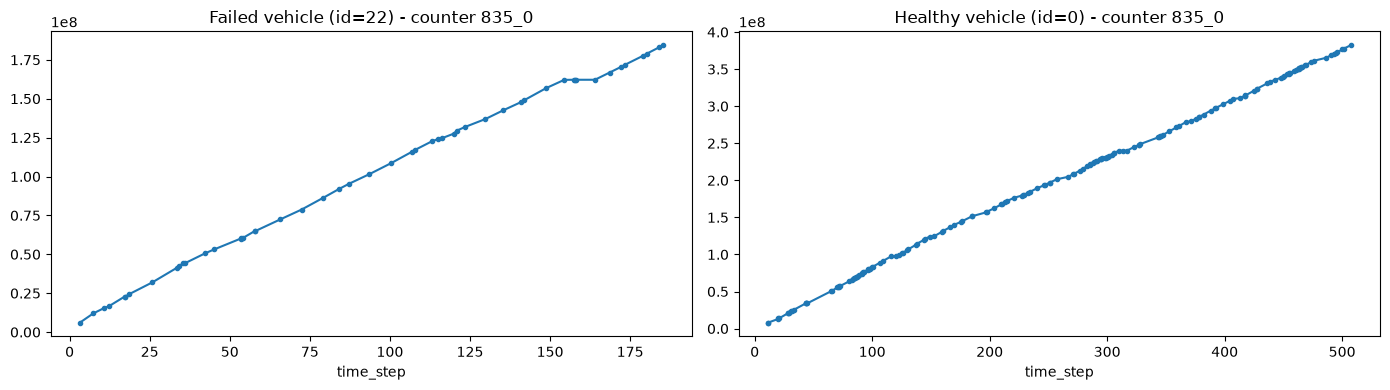

In [39]:
failed_id  = ops.loc[ops["in_study_repair"] == 1, "vehicle_id"].iloc[0]
healthy_id = ops.loc[ops["in_study_repair"] == 0, "vehicle_id"].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, vid, title in [(axes[0], failed_id, "Failed vehicle"),
                        (axes[1], healthy_id, "Healthy vehicle")]:
    v = ops[ops["vehicle_id"] == vid]
    ax.plot(v["time_step"], v["835_0"], marker="o", ms=3)
    ax.set_title(f"{title} (id={vid}) - counter 835_0")
    ax.set_xlabel("time_step")

plt.tight_layout()
plt.show()

In [40]:
ops["835_0"].describe()

count    1.122413e+06
mean     1.461318e+08
std      1.113199e+08
min      0.000000e+00
25%      6.079790e+07
50%      1.232031e+08
75%      2.070904e+08
max      1.022947e+09
Name: 835_0, dtype: float64

In [41]:
# Sort so that diff() within each vehicle follows time order
ops = ops.sort_values(["vehicle_id", "time_step"]).reset_index(drop=True)

g = ops.groupby("vehicle_id")

# Time elapsed since previous readout (uneven sampling!)
ops["dt"] = g["time_step"].diff()

for c in counter_cols:
    delta = g[c].diff()

    # Cumulative counters can't decrease -> negative delta = ECU reset artifact
    # (like the dip we saw in vehicle 22). Clip to 0, but keep a flag.
    ops[f"{c}_reset"] = (delta < 0).astype(int)
    delta = delta.clip(lower=0)

    # Usage rate = how much the counter grew per time unit
    ops[f"{c}_rate"] = delta / ops["dt"]

# First readout of each vehicle has no previous readout -> NaN. Fill with 0.
rate_cols  = [f"{c}_rate"  for c in counter_cols]
reset_cols = [f"{c}_reset" for c in counter_cols]
ops[rate_cols] = ops[rate_cols].fillna(0)

print(ops[["vehicle_id", "time_step", "dt", "835_0", "835_0_rate", "835_0_reset"]].head(8))
print("\nTotal reset artifacts found:", ops[reset_cols].sum().sum())

C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\2890795325.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ops["dt"] = g["time_step"].diff()
C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\2890795325.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ops[f"{c}_reset"] = (delta < 0).astype(int)
C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\2890795325.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

   vehicle_id  time_step   dt       835_0    835_0_rate  835_0_reset
0           0       11.2  NaN   8036751.0  0.000000e+00            0
1           0       11.4  0.2   8040811.0  2.030000e+04            0
2           0       19.6  8.2  12777022.0  5.775867e+05            0
3           0       20.2  0.6  13612083.0  1.391768e+06            0
4           0       21.0  0.8  14041353.0  5.365875e+05            0
5           0       28.0  7.0  20443403.0  9.145786e+05            0
6           0       28.6  0.6  21355593.0  1.520317e+06            0
7           0       29.4  0.8  21467573.0  1.399750e+05            0

Total reset artifacts found: 7


In [42]:
raw_cols = [c for c in train_ops.columns if c not in ("vehicle_id", "time_step")]

groups = {}
for col in raw_cols:
    var_id = col.split("_")[0]
    groups.setdefault(var_id, []).append(col)

for var, cols in sorted(groups.items()):
    kind = "COUNTER" if len(cols) == 1 else "HISTOGRAM"
    print(f"{var}: {kind} ({len(cols)} column{'s' if len(cols)>1 else ''})")

100: COUNTER (1 column)
158: HISTOGRAM (10 columns)
167: HISTOGRAM (10 columns)
171: COUNTER (1 column)
272: HISTOGRAM (10 columns)
291: HISTOGRAM (11 columns)
309: COUNTER (1 column)
370: COUNTER (1 column)
397: HISTOGRAM (36 columns)
427: COUNTER (1 column)
459: HISTOGRAM (20 columns)
666: COUNTER (1 column)
835: COUNTER (1 column)
837: COUNTER (1 column)


In [43]:
for var, cols in hist_groups.items():
    row_total = ops[cols].sum(axis=1)

    # Normalize each histogram row to shares that sum to 1.
    # A vehicle's *distribution* of operating conditions is comparable
    # across vehicles; raw counts just grow with age.
    shares = ops[cols].div(row_total.replace(0, np.nan), axis=0)
    share_cols = [f"{c}_share" for c in cols]
    ops[share_cols] = shares.fillna(0)

print("Columns now:", ops.shape[1])
# Sanity check: shares of one histogram should sum to ~1
check = ops[[f"{c}_share" for c in hist_groups["167"]]].sum(axis=1)
print("Histogram 167 share sums (should be ~1 or 0):", check.round(3).value_counts().head())

C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\168292694.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ops[share_cols] = shares.fillna(0)
C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\168292694.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ops[share_cols] = shares.fillna(0)
C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\168292694.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all column

Columns now: 224
Histogram 167 share sums (should be ~1 or 0): 1.0    1119590
0.0       2862
Name: count, dtype: int64


C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\168292694.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ops[share_cols] = shares.fillna(0)
C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\168292694.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ops[share_cols] = shares.fillna(0)
C:\Users\rajak\AppData\Local\Temp\ipykernel_12724\168292694.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all column

In [44]:
ops.describe()

,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,167_4,167_5,167_6,167_7,167_8,167_9,309_0,272_0,272_1,272_2,272_3,272_4,272_5,272_6,272_7,272_8,272_9,835_0,370_0,291_0,291_1,291_2,291_3,291_4,291_5,291_6,291_7,291_8,291_9,291_10,158_0,158_1,158_2,158_3,158_4,158_5,158_6,158_7,158_8,158_9,100_0,459_0,459_1,459_2,459_3,459_4,459_5,459_6,459_7,459_8,...,158_6_share,158_7_share,158_8_share,158_9_share,459_0_share,459_1_share,459_2_share,459_3_share,459_4_share,459_5_share,459_6_share,459_7_share,459_8_share,459_9_share,459_10_share,459_11_share,459_12_share,459_13_share,459_14_share,459_15_share,459_16_share,459_17_share,459_18_share,459_19_share,397_0_share,397_1_share,397_2_share,397_3_share,397_4_share,397_5_share,397_6_share,397_7_share,397_8_share,397_9_share,397_10_share,397_11_share,397_12_share,397_13_share,397_14_share,397_15_share,397_16_share,397_17_share,397_18_share,397_19_share,397_20_share,397_21_share,397_22_share,397_23_share,397_24_share,397_25_share,397_26_share,397_27_share,397_28_share,397_29_share,397_30_share,397_31_share,397_32_share,397_33_share,397_34_share,397_35_share
count,1.122452e+06,1.122452e+06,1.122452e+06,1.122412e+06,1.116047e+06,1.122413e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.119590e+06,1.122418e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.121927e+06,1.122413e+06,1.116054e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.112824e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.121804e+06,1.116051e+06,1.114099e+06,1.114099e+06,1.114099e+06,1.114099e+06,1.114099e+06,1.114099e+06,1.114099e+06,1.114099e+06,1.114099e+06,...,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06,1.122452e+06
mean,1.563501e+04,1.426336e+02,3.432285e+06,1.220519e+05,1.297269e+08,4.432735e+04,1.231484e+04,6.578556e+06,1.647673e+07,1.348033e+07,3.948936e+07,1.291043e+08,1.616505e+07,1.237457e+06,1.130708e+05,2.513515e+04,1.160704e+04,9.095183e+06,8.871166e+06,6.888060e+06,3.545662e+07,1.335260e+08,5.968650e+06,5.303856e+04,2.408601e+03,4.547189e+02,2.698576e+02,1.461318e+08,6.571623e+06,2.458236e+04,6.254047e+04,1.036058e+06,1.963723e+04,6.725472e+03,4.608888e+03,8.919470e+03,6.189571e+03,5.234454e+03,1.506462e+04,1.904895e+04,3.089379e+06,4.828619e+07,6.459712e+07,2.484140e+07,1.706263e+07,9.259272e+06,5.636848e+06,4.753604e+06,4.354528e+06,2.592706e+06,1.425511e+07,4.258535e+03,1.169722e+03,1.173479e+03,1.380093e+03,1.625984e+03,1.849545e+03,2.204264e+03,2.558352e+03,6.355295e+03,...,2.960777e-02,2.497036e-02,2.255456e-02,1.311547e-02,4.061263e-02,1.088299e-02,1.047542e-02,1.211702e-02,1.390133e-02,1.555618e-02,1.819170e-02,2.089961e-02,5.079101e-02,6.222157e-02,3.805247e-02,4.470530e-02,5.224986e-02,7.726329e-02,1.963961e-01,3.044579e-01,2.365757e-02,8.301357e-05,1.509973e-05,2.818843e-05,1.676972e-01,1.093481e-01,8.780750e-02,9.633766e-03,5.022181e-03,9.364378e-04,1.038910e-01,5.914689e-02,1.178359e-01,5.769472e-03,1.061365e-03,6.745866e-05,1.500802e-02,3.942059e-02,1.076171e-01,5.6

In [45]:
# One-hot encode the 8 categorical specs (Cat0...Cat28 values)
spec_encoded = pd.get_dummies(train_spec, columns=[c for c in train_spec.columns if c != "vehicle_id"],
                              prefix_sep="=")
print("Spec columns after encoding:", spec_encoded.shape[1])

ops = ops.merge(spec_encoded, on="vehicle_id", how="left")

# Define final feature set
share_cols_all = [c for c in ops.columns if c.endswith("_share")]
spec_cols      = [c for c in spec_encoded.columns if c != "vehicle_id"]

feature_cols = counter_cols + rate_cols + reset_cols + share_cols_all + spec_cols + ["time_step"]
print("Total features:", len(feature_cols))

Spec columns after encoding: 91
Total features: 212


In [47]:
keep = ["vehicle_id", "time_step", "class_label"] + feature_cols
keep = list(dict.fromkeys(keep))          # remove duplicates, keep first occurrence

model_df = ops[keep].copy()

model_df.to_parquet(DATA_DIR + "train_features.parquet", index=False)
print("Saved:", model_df.shape)

Saved: (1122452, 214)


In [48]:
model_df.head()

,vehicle_id,time_step,class_label,171_0,666_0,427_0,837_0,309_0,835_0,370_0,100_0,171_0_rate,666_0_rate,427_0_rate,837_0_rate,309_0_rate,835_0_rate,370_0_rate,100_0_rate,171_0_reset,666_0_reset,427_0_reset,837_0_reset,309_0_reset,835_0_reset,370_0_reset,100_0_reset,167_0_share,167_1_share,167_2_share,167_3_share,167_4_share,167_5_share,167_6_share,167_7_share,167_8_share,167_9_share,272_0_share,272_1_share,272_2_share,272_3_share,272_4_share,272_5_share,272_6_share,272_7_share,272_8_share,272_9_share,291_0_share,291_1_share,291_2_share,291_3_share,291_4_share,291_5_share,291_6_share,291_7_share,291_8_share,291_9_share,291_10_share,158_0_share,158_1_share,...,Spec_1=Cat8,Spec_1=Cat9,Spec_2=Cat0,Spec_2=Cat1,Spec_2=Cat10,Spec_2=Cat11,Spec_2=Cat12,Spec_2=Cat13,Spec_2=Cat14,Spec_2=Cat15,Spec_2=Cat16,Spec_2=Cat17,Spec_2=Cat18,Spec_2=Cat19,Spec_2=Cat2,Spec_2=Cat20,Spec_2=Cat3,Spec_2=Cat4,Spec_2=Cat5,Spec_2=Cat6,Spec_2=Cat7,Spec_2=Cat8,Spec_2=Cat9,Spec_3=Cat0,Spec_3=Cat1,Spec_3=Cat2,Spec_3=Cat3,Spec_4=Cat0,Spec_4=Cat1,Spec_5=Cat0,Spec_5=Cat1,Spec_5=Cat2,Spec_5=Cat3,Spec_5=Cat4,Spec_6=Cat0,Spec_6=Cat1,Spec_6=Cat10,Spec_6=Cat11,Spec_6=Cat12,Spec_6=Cat13,Spec_6=Cat15,Spec_6=Cat17,Spec_6=Cat18,Spec_6=Cat2,Spec_6=Cat3,Spec_6=Cat4,Spec_6=Cat5,Spec_6=Cat6,Spec_6=Cat7,Spec_6=Cat8,Spec_6=Cat9,Spec_7=Cat0,Spec_7=Cat1,Spec_7=Cat2,Spec_7=Cat3,Spec_7=Cat4,Spec_7=Cat5,Spec_7=Cat6,Spec_7=Cat7,Spec_7=Cat8
0,0,11.2,0,167985.0,10787.0,7413813.0,2296.0,70.0,8036751.0,0.0,858410.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000e+00,0.0,0.000000,0,0,0,0,0,0,0,0,0.000328,0.103409,0.129879,0.050280,0.101264,0.380715,0.215901,0.017726,0.000498,0.0,0.130602,0.078053,0.034999,0.060851,0.658875,0.036265,0.000354,0.0,0.0,0.0,0.197871,0.089502,0.074665,0.149169,0.075472,0.036284,0.086276,0.083212,0.079342,0.117562,0.010643,0.009569,0.265214,...,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,0,11.4,0,167985.0,10787.0,7413813.0,2296.0,70.0,8040811.0,0.0,860571.0,0.000000,0.000000,0.000000e+00,0.000000,0.0,2.030000e+04,0.0,10805.000000,0,0,0,0,0,0,0,0,0.000328,0.103869,0.129812,0.050254,0.101212,0.380520,0.215790,0.017717,0.000497,0.0,0.131043,0.078013,0.034982,0.060820,0.658541,0.036247,0.000354,0.0,0.0,0.0,0.198068,0.089855,0.074557,0.148953,0.075523,0.036393,0.086151,0.083092,0.079388,0.117391,0.010628,0.009564,0.265380,...,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,0,19.6,0,331635.0,14525.0,13683604.0,2600.0,70.0,12777022.0,0.0,1379191.0,19957.317073,455.853659,7.646087e+05,37.073171,0.0,5.775867e+05,0.0,63246.341463,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.102363,0.064882,0.034261,0.066824,0.705095,0.026353,0.000223,0.0,0.0,0.0,0.215084,0.096063,0.085591,0.142987,0.072702,0.041486,0.088611,0.067063,0.059007,0.115094,0.016313,0.011267,0.263567,...,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,0,20.2,0,354975.0,15015.0,14540449.0,2616.0,70.0,13612083.0,0.0,1428606.0,38900.000000,816.666667,1.428075e+06,26.666667,0.0,1.391768e+06,0.0,82358.333333,0,0,0,0,0,0,0,0,0.000000,0.000000,0.00

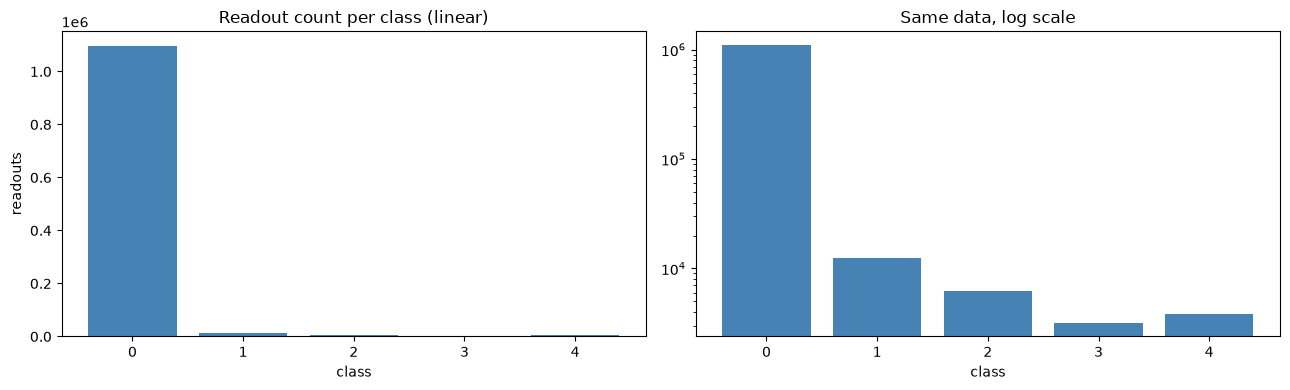

class_label
0    97.71 %
1     1.11 %
2     0.55 %
3     0.29 %
4     0.34 %
Name: count, dtype: str


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = model_df["class_label"].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color="steelblue")
axes[0].set_title("Readout count per class (linear)")
axes[0].set_xlabel("class"); axes[0].set_ylabel("readouts")

axes[1].bar(counts.index.astype(str), counts.values, color="steelblue")
axes[1].set_yscale("log")
axes[1].set_title("Same data, log scale")
axes[1].set_xlabel("class")

plt.tight_layout(); plt.show()

print((counts / counts.sum() * 100).round(2).astype(str) + " %")

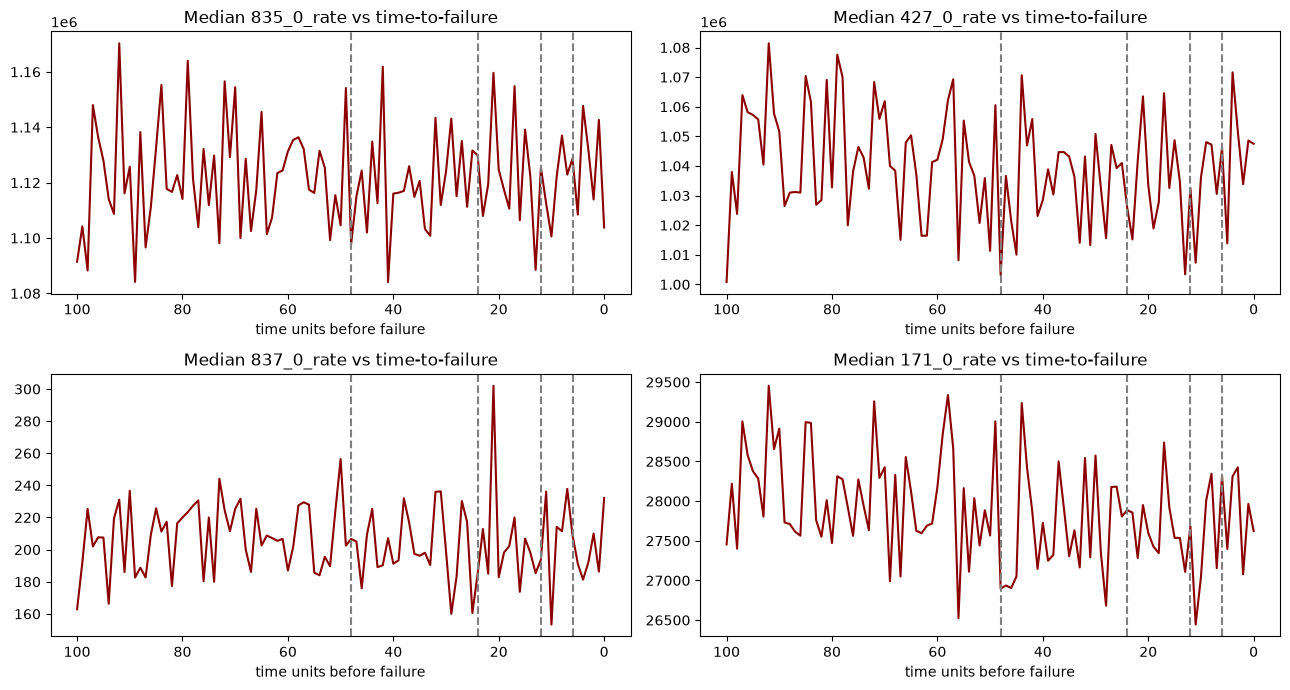

In [27]:
failed = model_df.merge(train_tte, on="vehicle_id")
failed = failed[failed["in_study_repair"] == 1].copy()
failed["ttf"] = failed["length_of_study_time_step"] - failed["time_step"]
failed = failed[failed["ttf"] <= 100]          # last 100 time units before failure

check_feats = ["835_0_rate", "427_0_rate", "837_0_rate", "171_0_rate"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, f in zip(axes.ravel(), check_feats):
    med = failed.groupby(failed["ttf"].round(0))[f].median()
    ax.plot(med.index, med.values, color="darkred")
    ax.invert_xaxis()                           # failure at the right edge
    ax.axvline(48, ls="--", c="gray"); ax.axvline(24, ls="--", c="gray")
    ax.axvline(12, ls="--", c="gray"); ax.axvline(6, ls="--", c="gray")
    ax.set_title(f"Median {f} vs time-to-failure")
    ax.set_xlabel("time units before failure")

plt.tight_layout(); plt.show()

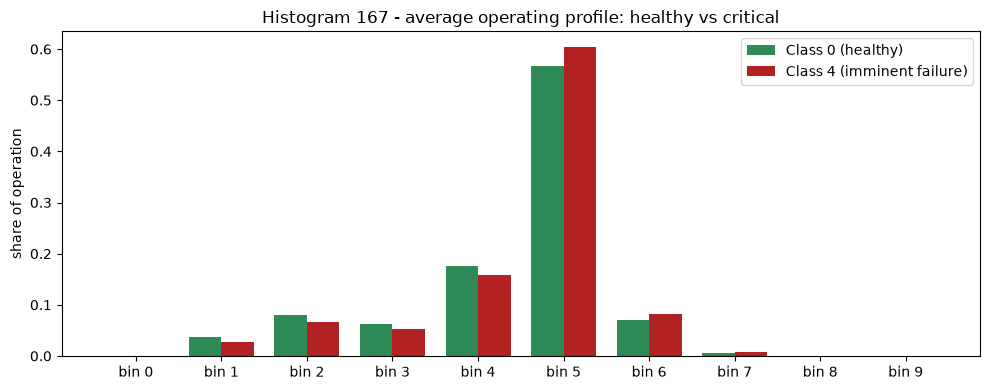

In [28]:
share_167 = [f"167_{i}_share" for i in range(10)]

healthy_prof = model_df.loc[model_df["class_label"] == 0, share_167].mean()
crit_prof    = model_df.loc[model_df["class_label"] == 4, share_167].mean()

x = np.arange(10); w = 0.38
plt.figure(figsize=(10, 4))
plt.bar(x - w/2, healthy_prof.values, w, label="Class 0 (healthy)", color="seagreen")
plt.bar(x + w/2, crit_prof.values,    w, label="Class 4 (imminent failure)", color="firebrick")
plt.xticks(x, [f"bin {i}" for i in range(10)])
plt.title("Histogram 167 - average operating profile: healthy vs critical")
plt.ylabel("share of operation"); plt.legend()
plt.tight_layout(); plt.show()

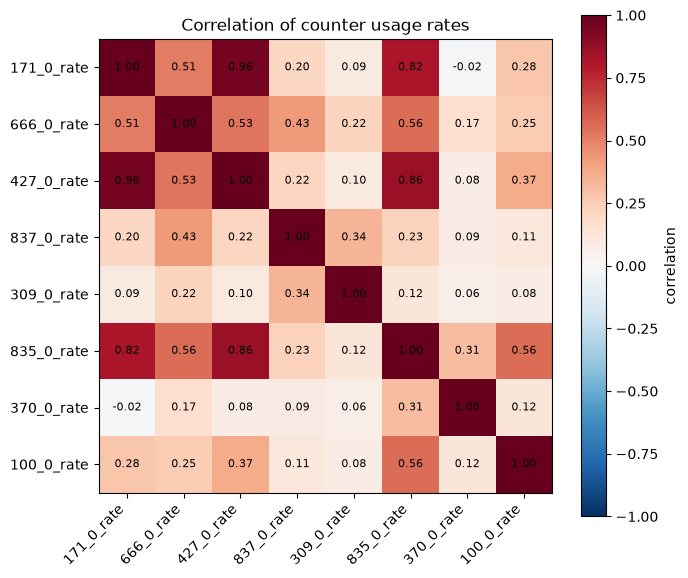

In [50]:
import matplotlib

corr = model_df[rate_cols].corr()

plt.figure(figsize=(7, 6))
im = plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="correlation")
plt.xticks(range(len(rate_cols)), rate_cols, rotation=45, ha="right")
plt.yticks(range(len(rate_cols)), rate_cols)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Correlation of counter usage rates")
plt.tight_layout(); plt.show()

status
healthy        8000
pre-failure    8000
Name: count, dtype: int64


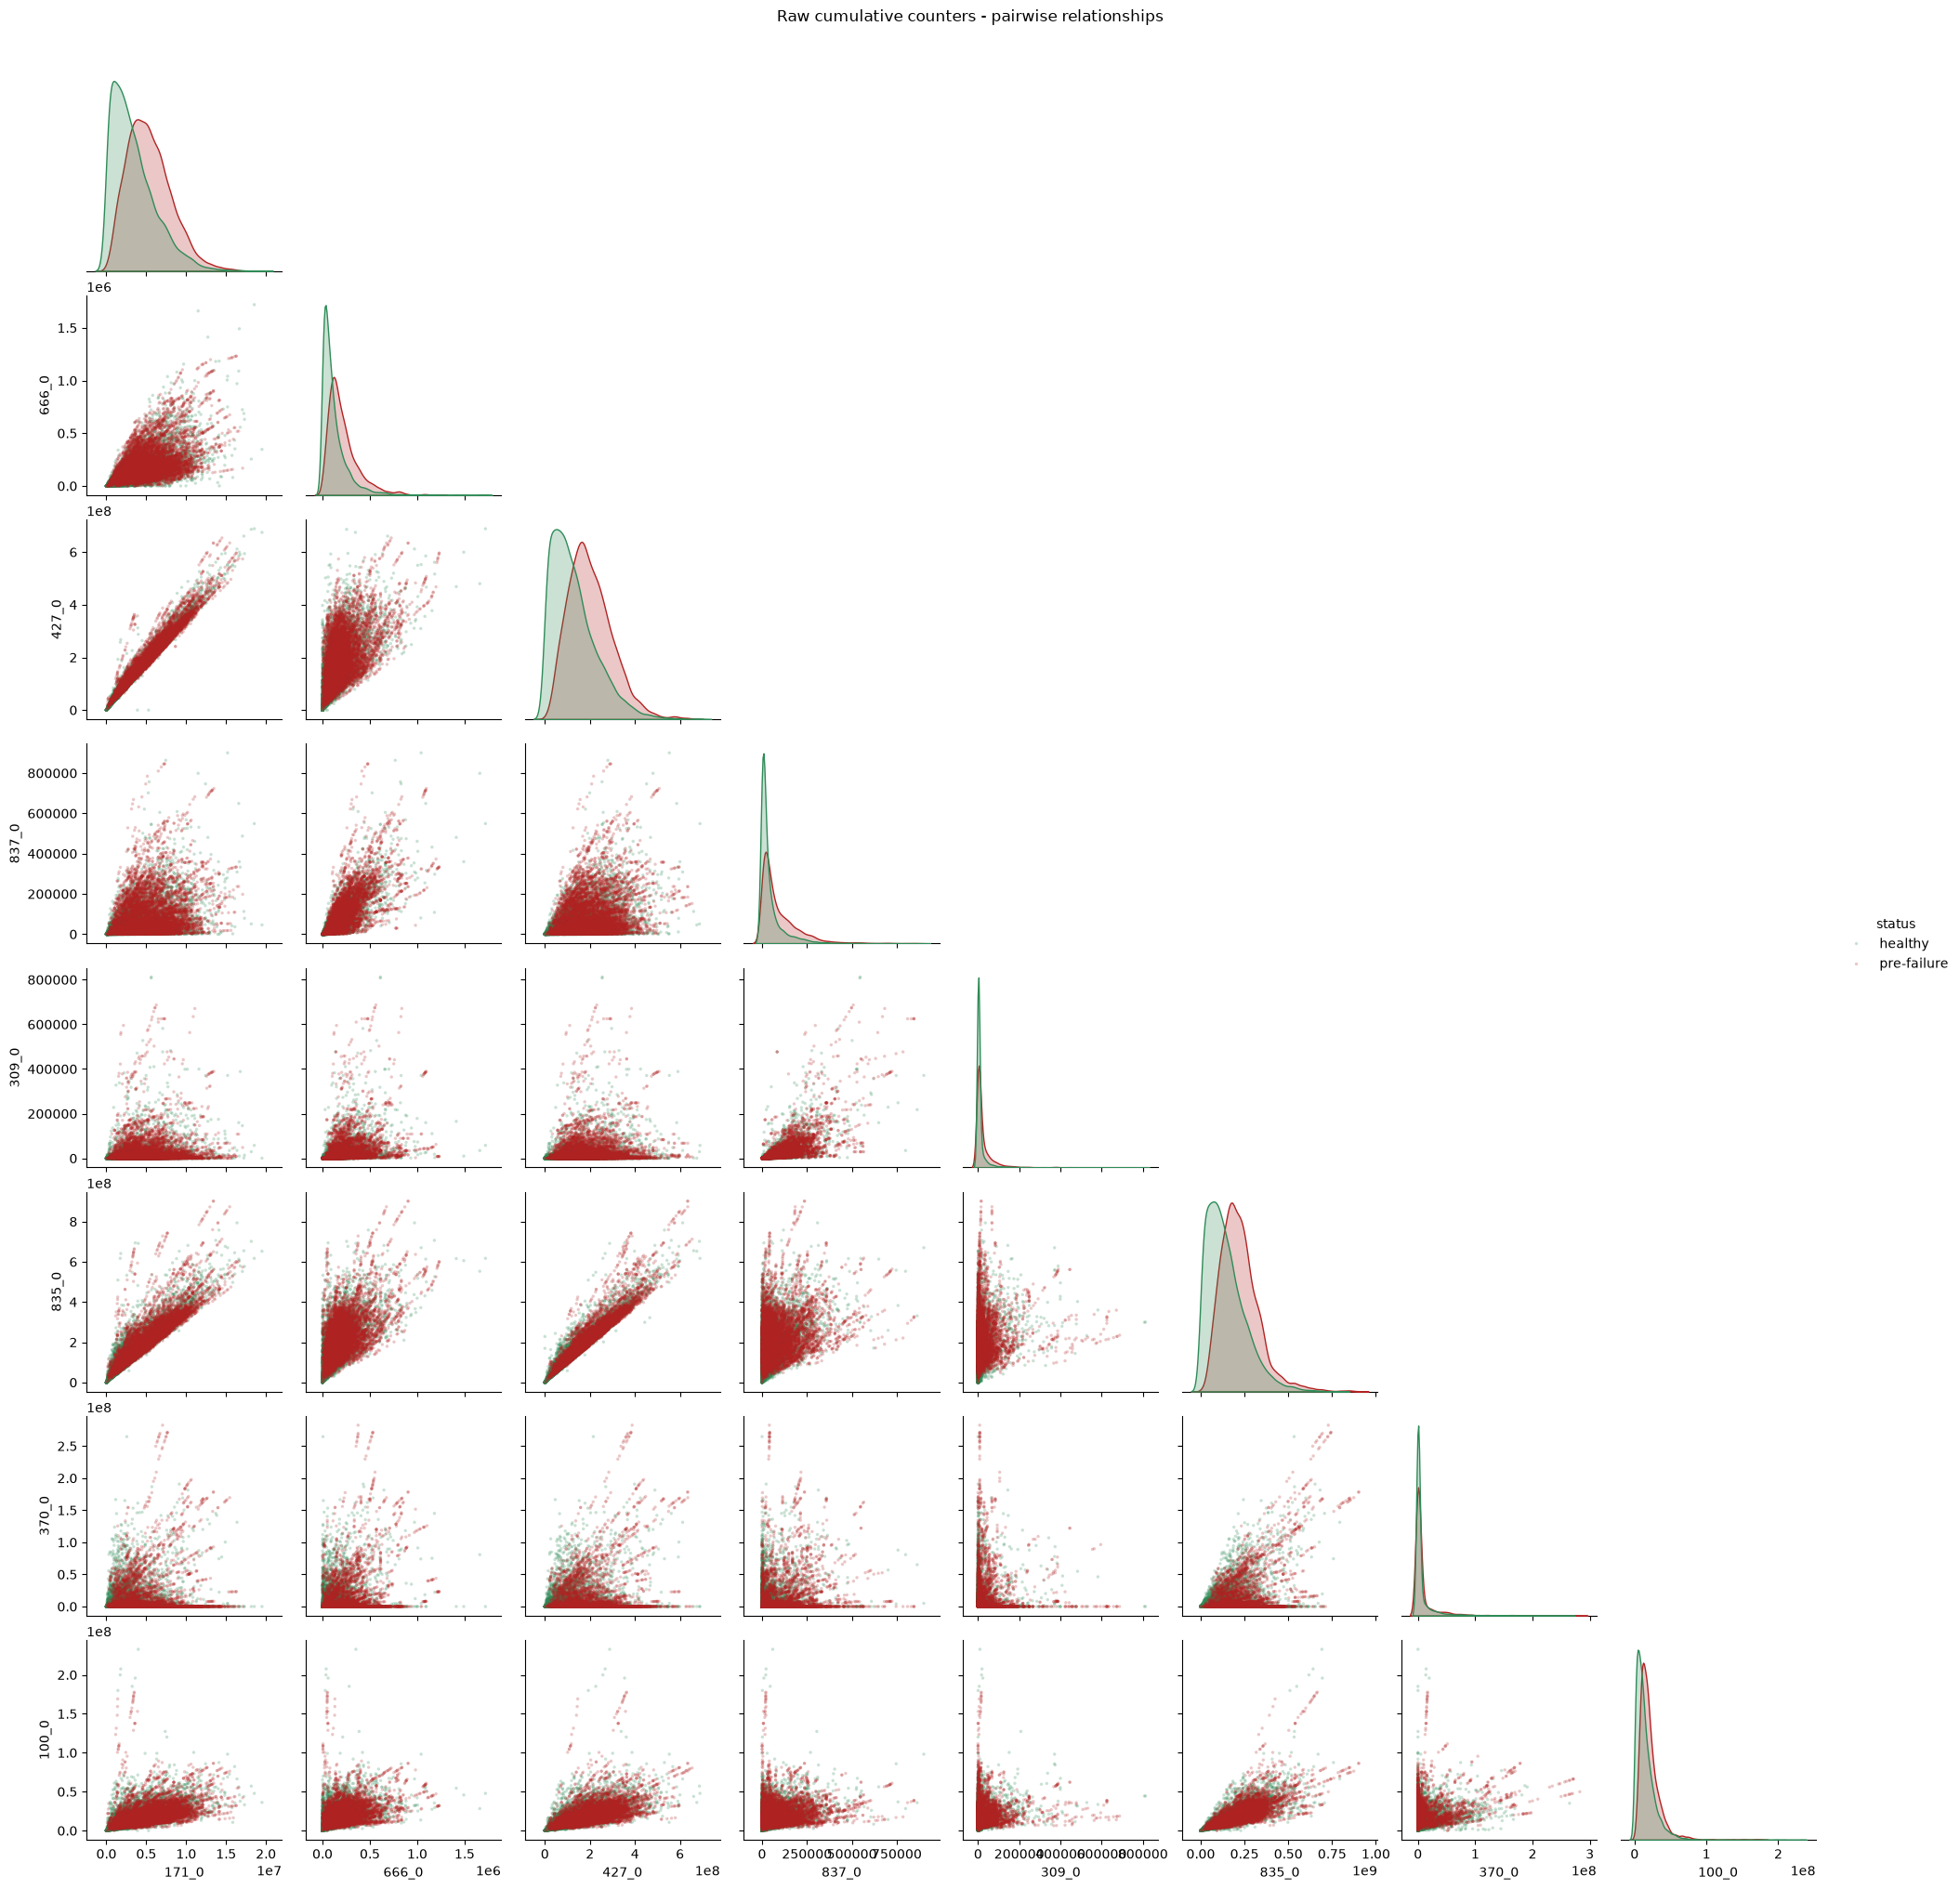

: 

In [ ]:
# Binary color: healthy readouts vs warning-zone readouts (classes 1-4)
model_df["status"] = np.where(model_df["class_label"] == 0, "healthy", "pre-failure")

# Stratified sample: pairplots choke beyond ~20K points.
# Take ALL pre-failure rows are too many too - sample both groups.
n_per_group = 8000
sample = (
    model_df.groupby("status", group_keys=False)
            .sample(n=n_per_group, random_state=42)
)
print(sample["status"].value_counts())

g = sns.pairplot(sample[counter_cols + ["status"]],
                 hue="status",
                 corner=True,                     # lower triangle only - halves the panels
                 plot_kws=dict(s=6, alpha=0.25, linewidth=0),
                 diag_kind="kde",
                 palette={"healthy": "seagreen", "pre-failure": "firebrick"})
g.figure.suptitle("Raw cumulative counters - pairwise relationships", y=1.02)
plt.show()

In [1]:
from scipy.stats import mannwhitneyu

# --- 1. Effect size on raw counters (not just p-values) ---
def cliffs_delta(a, b, n=20000, seed=0):
    rng = np.random.default_rng(seed)
    a_s = rng.choice(a, size=min(n, len(a)), replace=False)
    b_s = rng.choice(b, size=min(n, len(b)), replace=False)
    u, p = mannwhitneyu(a_s, b_s, alternative="two-sided")
    delta = 2 * u / (len(a_s) * len(b_s)) - 1     # rank-biserial / Cliff's delta
    return delta, p

print(f"{'feature':<12} {'delta':>8} {'p':>10}   interpretation")
for c in counter_cols:
    h = model_df.loc[model_df["class_label"] == 0, c].dropna().values
    f = model_df.loc[model_df["class_label"] > 0, c].dropna().values
    d, p = cliffs_delta(h, f)
    mag = "negligible" if abs(d) < .147 else "small" if abs(d) < .33 else "medium" if abs(d) < .474 else "large"
    print(f"{c:<12} {d:>8.3f} {p:>10.2e}   {mag}")

feature         delta          p   interpretation


NameError: name 'counter_cols' is not defined